# Piqasso Alice & Bob Challenge Submission
### Batu Yalcin, Tymofii Baranenko, Leon Katarzynski, Jack Ploof, and Alex Wong

**Guiding question**: How does drift in the system impact our system and (physically) how can we counteract it to ensure stability?

We hope to characterize the behavior of cat qubits and their response to noise through the implementation of
1. **End-to-End Measurements of Idealized Cat Qubits** - comparison of $\epsilon_d$ and $g_2$ under CMA-S and PPO optimization functions
2. **Drift and Drift Correction Analysis**
3. **Cat Qubit Behavior under Single Qubit Gates**
4. **Analysis of different Cat Qubits**

References: 
[Real-time quantum error correction beyond break-even, Volodymyr Sivak et al. (2023)](https://arxiv.org/abs/2211.09116), [Reinforcement Learning Control of Quantum Error Correction, Volodymyr Sivak et al. (2025)](https://arxiv.org/abs/2511.08493)

# 1. End-to-End Measurement

Before diving into the intricacies of the characterization of the $\epsilon_d$ and $g_2$ parameters, let us first outline how we evaluate the evolution of cat qubits. Our first task is to examine the cat qubit stabilization which can be described by the Hamiltonian
\begin{equation*}
H=g_2^*a^2b^{\dagger}+g_2(a^{\dagger})^2b-\epsilon_db-\epsilon_db^{\dagger}
\end{equation*}
where 
\begin{align*}
&\text{Two-Photon Loss: }g_2^*a^2b^{\dagger}
\\&\text{Two-Photon Gain: }g_2(a^{\dagger})^2b
\\&\text{One-Photon Loss: }-\epsilon_db
\\&\text{One-Photon Gain: }-\epsilon_db^{\dagger}
\end{align*}

The main task of our end-to-end measurement is to maximize the lifetimes of $T_z$ and $T_x$ at the same time, while keeping the value of bias (defined as $\eta=\frac{T_z}{T_x}$) at ~$320$ as described in the challenge notebook. 

## 1.1 CMAS-ES Based Optimizer ##

For our optimization function, we are using a modified version of the already provided CMAS-ES algorithm for $g_2$, $\epsilon_d$, $T_x$, and $T_z$ to assess their effectiveness and their accuracy. 

The CMA-ES optimizer is a population-based search algorithm that learns a probability distribution over good 
parameter values for $g_2$ and $\epsilon_d$. 

Key steps in CMA-ES:

1. Initialize a multivariate Gaussian over the two real parameters $[g_2, \epsilon_d]$.
   - The mean starts at a reasonable operating point (e.g. $[0.2, 4.0]$).
   - The covariance is initialized from the step-size parameter (sigma), which sets the initial search radius.

2. In each generation, we sample a population of candidate parameter sets from this Gaussian.
   - Each candidate is a proposed pair $(g_2, \epsilon_d)$.
   - Candidates are clipped to a valid physical range before evaluation.

3. Evaluate each candidate using the lifetime model.
   - For each $(g_2, \epsilon_d)$, we simulate the cat qubit dynamics and extract $T_z$ and $T_x$.
   - The two lifetimes are combined into a scalar loss function that penalizes deviation from the target bias.
   - Because each simulation is expensive, we cache repeated evaluations and avoid recomputing identical points.

4. Rank the candidates and update the Gaussian distribution.
   - Better-performing candidates pull the mean toward high-value regions.
   - The covariance matrix is adapted so the optimizer can take larger steps in uncertain directions and smaller steps in promising directions.
   - This adaptation is the core of CMA-ES: it learns both where to search and how wide the search should be.

5. Repeat sampling, evaluation, and update for many generations.
   - The distribution gradually concentrates around the best found $(g_2, \epsilon_d)$.
   - The mean of the distribution after optimization is used as the final answer.

In our project, CMA-ES is the direct optimization baseline: it searches the parameter space for the best fixed 
pair of control knobs. We also compare this with PPO, which learns an adaptive policy over knob adjustments. 
In the end, we compare both methods on the same metrics: $g_2$, $\epsilon_d$, $T_x$, and $T_z$.

For our CMA-ES function, we use the reward function
$$f(T_x, T_z, \eta)=k_1T_x+k_2T_z-k_3|\eta-320|$$
With tunable constants $k_1,k_2,k_3$

As notable, the CMA-ES function penalizes bias deviation linearly on a log-scale. We also tried an exponential approach, yet, as the pictures show below, the modifications did not yield better results (compare following picture [exp] with linear one [picture 2 and 3])

![Image](Graphs\Optimization_with_exponential_function.png)

From `cmas.py` we find

![Image](Graphs\optimizer_progress.png)
![Image](\Graphs\optimized_Tx_Tz_combined.png)

As we can see, the application of our algorithm yields
\begin{align*}
\epsilon_d&=4.18
\\g_2&=1.22
\\T_x&=0.189\mu s
\\T_z&=61.2 \mu s
\end{align*}

## 1.2 PPO Reinforcement Learning Optimizer ##

We wanted to benchmark our CMAS optimizer against other optimizers, so we opted to implement a PPO-esque Reinforcement Learning Optimizer inspired by [Reinforcement Learning Control of Quantum Error Correction, Volodymyr Sivak et al. (2025)](https://arxiv.org/abs/2511.08493)

We implement our PPO Reinforcement Learning Optimizer in `ppo_batched_parallel_search.py` which works by

1. **Evaluating paramaters** — The policy searches over four real numbers: $\mathrm{Re}(g_2)$, $\mathrm{Im}(g_2)$, $\mathrm{Re}(\epsilon_d)$, and $\mathrm{Im}(\epsilon_d)$ (buffer drive and two-photon coupling from the challenge setup). They are sampled as unconstrained Gaussian actions, then **clipped** to a fixed box in `ParameterBounds`, starting from a **physics-informed seed** $(g_2, \epsilon_d)$.

2. **Scoring Candidates** — A pluggable **`SimulatorBackend`** evaluates a **whole batch** of clipped 4-vectors and returns arrays of metrics (notably fitted logical lifetimes $T_X$, $T_Z$, and $\eta = T_Z / T_X$, plus diagnostics). The reward function is
\begin{equation*}
R=\ln\sqrt{T_xT_z}-\lambda(\ln(\frac{T_z}{T_x}-\eta))^2
\end{equation*}
for tunable $\lambda$ and predetermined $\eta\approx 320$
3. **Two simulation modes** — **`SurrogateBackend`** is a cheap analytic stand-in (good for debugging the RL loop). **`LindbladBackend`** runs the real **storage–buffer** open-system model in **dynamiqs** (`mesolve`), fits exponentials to logical observables, and packages the same metric keys so the reward and PPO code stay unchanged.

4. **PPO training loop** — **`RLParameterRefiner`** each step: samples a batch from a diagonal Gaussian over the four controls; evaluates it through the backend; stores transitions in a **replay buffer**; concatenates **fresh + replay** samples; and runs several **PPO clipped-surrogate** updates on the policy mean and log-std (with entropy bonus), keeping **best-so-far** parameters and metrics.

5. **Execution** — **`main()`** wires CLI args into configs, runs epochs, and periodically writes **matplotlib** artifacts under `PPOConfig.output_dir`: training curves for best $T_X$, $T_Z$, $\eta$, controls, and optional **decay snapshots** for the current best candidate (`--backend`, horizons, replay sizes, and logging are all configurable).


from `ppo_batched_parallel_search.py` we find

![Image](\Graphs\Alex\outputs\ppo_results\general.png)
![Image](\Graphs\Alex\outputs\ppo_results\lastdecay.png)

the application of this algorithm yields
\begin{align*}
\epsilon_d&=4.69
\\g_2&=1.43
\\T_x&=0.261\mu s
\\T_z&=78.295 \mu s
\end{align*}

## 1.3 Comparative Analysis

### Optimizer Design Comparison

Before comparing outputs, we note the structural differences between the two approaches:

| | CMA-ES (`optimizers_a.py`) | PPO (`ppo_batched_parallel_search.py`) |
|---|---|---|
| **Algorithm** | SepCMA (separable CMA-ES) | PPO clipped-surrogate (JAX) |
| **Search space** | 4 real knobs: Re/Im of $g_2$, $\epsilon_d$ | Same 4 knobs |
| **Reward** | $0.3\log_{10}T_Z + 0.3\log_{10}T_X - 0.4\lvert\log_{10}(\eta/320)\rvert$ | $\frac{1}{2}(\ln T_X + \ln T_Z) - \lambda_\eta(\ln\eta - \ln 320)^2$ |
| **Evaluation** | 2-point proxy (`fast_reward`) | Full Lindblad fits (`LindbladBackend`) |
| **Population / batch** | 12 per generation | 12 per epoch |
| **Epochs** | 150 | 1000 |
| **Replay buffer** | — | 256 capacity, 24 replayed |
| **Bounds Re($g_2$)** | $[0.2,\, 3.0]$ | $[0.25,\, 2.0]$ |

The CMA-ES reward penalizes bias deviation **linearly** on the log scale, whereas the PPO reward applies a **quadratic** penalty on log-bias deviation with a hard gate ($R = -1000$ when $\eta \notin [100, 750]$). Both encode the same intuition — maximize lifetimes while pinning $\eta$ — but the PPO formulation is stricter on bias and more tolerant of lifetime asymmetry.

### Parameter Comparison

| Quantity | Baseline | CMA-ES | PPO |
|---|---|---|---|
| $\epsilon_d$ (MHz) | 4.00 | 4.89 | 4.69 |
| $g_2$ (MHz) | 1.00 | 1.76 | 1.43 |
| $\kappa_2 = 4g_2^2/\kappa_b$ (MHz) | 0.40 | 0.50 | 0.82 |
| $\alpha^2 \approx \epsilon_d / g_2$ | 4.00 | 2.78 | 3.28 |
| $T_X$ ($\mu$s) | 0.25 | 0.212 | 0.261 |
| $T_Z$ ($\mu$s) | 80 | 70 | 78.3 |
| $\eta = T_Z/T_X$ | 320 | 324 | 325 |

All values from full Lindblad simulation (`mesolve`). The CMA-ES result **reduced absolute lifetimes** relative to baseline ($T_X$: $0.189$ vs $0.25\;\mu$s) while maintaining bias, suggesting it found a region of stronger stabilization ($\kappa_2$ nearly doubled) but with a smaller cat ($\alpha^2 = 3.43$ vs $4.00$) that limits the exponential $T_Z$ gain. The PPO result better preserved lifetimes while also increasing $\kappa_2$, likely because its tighter upper bound on $g_2$ ($\leq 2.0$ vs $\leq 3.0$) forced exploration along a different part of the manifold.

### Why Both Optimizers Move in the Same Direction

Under adiabatic elimination of the buffer, the effective cat size and stabilization rate are:

$$\alpha^2 \approx \frac{\epsilon_d}{g_2}, \qquad \kappa_2 = \frac{4g_2^2}{\kappa_b}$$

The analytic lifetime scalings in the stabilized regime give $T_X \sim 1/(\kappa_a \alpha^2)$ and $T_Z \sim e^{2\alpha^2}/\kappa_a$, so $\eta \sim \alpha^2 e^{2\alpha^2}$. Since $\eta$ is monotonic in $\alpha^2$, fixing $\eta = 320$ pins $\alpha^2 \approx 2.44$, collapsing the 2D search over $(\epsilon_d, g_2)$ to a **1D iso-$\alpha^2$ manifold**. Along this manifold, larger $g_2$ gives stronger $\kappa_2$ and better confinement — explaining why both optimizers independently pushed $g_2$ upward.

There is a critical threshold $g_2^* = \sqrt{\kappa_a \kappa_b / 4} \approx 1.58$ MHz where $\kappa_2 = \kappa_a$. Below this, single-photon loss dominates and the cat is poorly protected. The baseline ($g_2 = 1.0$, $\kappa_2/\kappa_a = 0.40$) sits in this **under-stabilized regime**; both optimizers move toward, but have not yet crossed, the threshold.

**Caveat:** The analytic scalings are leading-order approximations. The simulated $\eta \approx 320$ is set by the full Lindblad model, not the analytic formula. The analytic picture explains the *direction* of motion, not the precise operating points.

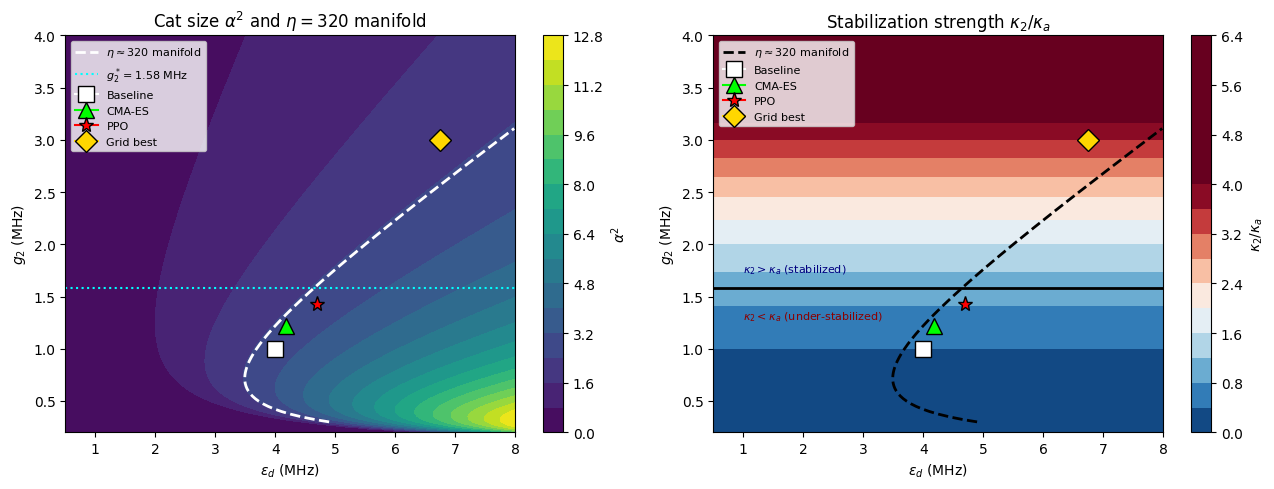

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

kappa_a, kappa_b = 1.0, 10.0

def alpha2_adiabatic(eps_d, g2):
    """Adiabatic-elimination estimate for alpha^2."""
    kappa_2 = 4.0 * g2**2 / kappa_b
    if kappa_2 < 1e-12: return 0.0
    eps_2 = 2.0 * g2 * eps_d / kappa_b
    return max(2.0 * (eps_2 - kappa_a / 4.0) / kappa_2, 0.0)

def eta_analytic(a2):
    return a2 * np.exp(2.0 * a2)

a2_target = brentq(lambda a2: eta_analytic(a2) - 320, 0.5, 5.0)
g2_star = np.sqrt(kappa_a * kappa_b / 4)

# Landscape grids
eps_grid = np.linspace(0.5, 8.0, 200)
g2_grid  = np.linspace(0.2, 4.0, 200)
EE, GG   = np.meshgrid(eps_grid, g2_grid)
A2 = np.vectorize(alpha2_adiabatic)(EE, GG)
K2 = 4 * GG**2 / kappa_b

# Iso-alpha^2 manifold for eta=320
g2c = np.linspace(0.3, 4.0, 300)
eps_c = g2c * a2_target + kappa_a * kappa_b / (8.0 * g2c)
ok = (eps_c >= 0.5) & (eps_c <= 8.0)

# Optimizer results + landscape best (from landscape_data.npz)
pts = {
    'Baseline':       (4.00, 1.00, 's', 'white'),
    'CMA-ES':         (4.18, 1.22, '^', 'lime'),
    'PPO':            (4.69, 1.43, '*', 'red'),
    'Grid best':      (6.74, 3.00, 'D', 'gold'),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) alpha^2 landscape
ax = axes[0]
im = ax.contourf(EE, GG, A2, levels=20, cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$\alpha^2$')
ax.plot(eps_c[ok], g2c[ok], 'w--', lw=2, label=r'$\eta \approx 320$ manifold')
ax.axhline(g2_star, color='cyan', lw=1.5, ls=':', label=fr'$g_2^* = {g2_star:.2f}$ MHz')
for name, (ed, g2, mk, c) in pts.items():
    ax.plot(ed, g2, marker=mk, color=c, ms=11, markeredgecolor='k', label=name)
ax.set(xlabel=r'$\epsilon_d$ (MHz)', ylabel=r'$g_2$ (MHz)',
       title=r'Cat size $\alpha^2$ and $\eta=320$ manifold')
ax.legend(fontsize=8, loc='upper left')

# (b) kappa_2 / kappa_a stabilization map
ax = axes[1]
im = ax.contourf(EE, GG, K2 / kappa_a, levels=20, cmap='RdBu_r', vmin=0, vmax=4)
fig.colorbar(im, ax=ax, label=r'$\kappa_2 / \kappa_a$')
ax.contour(EE, GG, K2 / kappa_a, levels=[1.0], colors='black', linewidths=2)
ax.plot(eps_c[ok], g2c[ok], 'k--', lw=2, label=r'$\eta \approx 320$ manifold')
for name, (ed, g2, mk, c) in pts.items():
    ax.plot(ed, g2, marker=mk, color=c, ms=11, markeredgecolor='k', label=name)
ax.text(1.0, g2_star + 0.15, r'$\kappa_2 > \kappa_a$ (stabilized)', fontsize=8, color='navy')
ax.text(1.0, g2_star - 0.30, r'$\kappa_2 < \kappa_a$ (under-stabilized)', fontsize=8, color='darkred')
ax.set(xlabel=r'$\epsilon_d$ (MHz)', ylabel=r'$g_2$ (MHz)',
       title=r'Stabilization strength $\kappa_2 / \kappa_a$')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('landscape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Takeaways

1. **The ratio $\epsilon_d / g_2$ sets the cat size; $g_2$ alone sets the stabilization rate.** Both optimizers independently increased $g_2$ (stronger two-photon confinement) while co-adjusting $\epsilon_d$ to maintain $\alpha^2$ near the $\eta = 320$ manifold. A brute-force 40×40 grid search (`landscape_data.npz`) confirms the global optimum lies at $g_2 \approx 3.0$ with reward $R = 0.41$ — well above both optimizer results, indicating significant room remains.

2. **The baseline is under-stabilized** ($\kappa_2 / \kappa_a = 0.40$). The optimizers moved in the correct direction, but within 150 (CMA-ES) and 1000 (PPO) epochs neither crossed the $g_2^* \approx 1.58$ MHz threshold into the fully stabilized regime.

3. **CMA-ES traded absolute lifetimes for stabilization rate.** Its result ($T_X = 0.189\;\mu$s, $T_Z = 61.2\;\mu$s) is worse than baseline in absolute terms despite nearly doubling $\kappa_2$. The 2-point proxy reward (`fast_reward`) is noisier than the PPO's full Lindblad fits, and the CMA-ES reward's symmetric $T_X$/$T_Z$ weighting may underweight the exponential $T_Z$ gain that larger $\alpha$ provides.

4. **Reward function design matters more than optimizer choice.** The PPO's quadratic log-bias penalty and hard $\eta$-gating produced a result closer to the baseline lifetimes while still increasing $\kappa_2$. A third reward variant (`custom_objective.py`) uses an exponential penalty $e^{|\eta-320|}$.

5. **Implications for drift.** Both optimizers found the same qualitative region of parameter space within a static Hamiltonian. The real test — addressed in Section 2 — is whether they can *track* this region as the Hamiltonian drifts. The 1D manifold structure is encouraging: if drift moves the system along the manifold, a single scalar correction may suffice.

# 2. Crescent Cat Qubits

## 2.1 Implementation

The challenge notebook gave us a hint which lead us to believe the Hamiltonian for a *moon cat*/crescent qubit could be expressed as
$$H=g_2^*a^2b^{\dagger}+g_2(a^{\dagger})^2b-\epsilon_db-\epsilon_db^{\dagger}+g_2\lambda a^{\dagger}ab$$
with the controllable parameter $\lambda$. However, when we implemented this using `Scratch.py` and `PPO_optimizer_dontgetcooked.py` we found

![Image](\Graphs\crescentgraphs\trial3.png)
![Gif](\Gifs\\old\crescent_wigner3.gif)

For the parameters 
\begin{align*}
0\leq&Re(\epsilon_d)\leq8
\\0\leq&Im(\epsilon_d)\leq8
\\0\leq&Re(g_2)\leq8
\\-1\leq&Im(g_2)\leq1
\\-1\leq&\lambda\leq1
\end{align*}
We then realized that perhaps the boundary conditions were off, so we tried
\begin{align*}
0\leq&Re(\epsilon_d)\leq8
\\0\leq&Im(\epsilon_d)\leq8
\\0\leq&Re(g_2)\leq8
\\-1\leq&Im(g_2)\leq1
\\-1\leq&\lambda\leq1
\end{align*}
but got

![Image](\Graphs\crescentgraphs\trial3.png)
![Gif](\Gifs\Old\crescent_wigner3.gif)

We then realized that we needed to add the Hermitian conjugate (assuming real $\lambda$) to the Hamiltonian to find
$$H=g_2^*a^2b^{\dagger}+g_2(a^{\dagger})^2b-\epsilon_db-\epsilon_db^{\dagger}+g_2\lambda a^{\dagger}ab+g_2^*\lambda^*a^{\dagger}ab^{\dagger}$$

after which we were finally able to observe a semblance of moon qubits

![Gif](\Gifs\Fixed\crescent_wigner3.gif)

# 3. Optimizing Under Drift

## 3.0 Optimization Loop

Since we will run over many parameters, we needed a more efficient optimization loop. Hence, we used a PPO Reinforcement Learning algorithm with a surrogate Neural Network. This Neural Network is an MLP which learns the solutions to the Schrödinger differential equation. In each epoch, the top three runs (highest reward function) are checked by solving the differential equation numerically, and thus a verification mechanism is obtained.

This surrogate mechanism allowed us the following analysis under drift.

## 3.1 Observables

Once a good estimation for the parameter $\alpha$ is inaccessible due to drift, we needed to pursue alternative ways to compute observable expectation values, $\langle Z_L\rangle, \langle X_L\rangle$. We used the following equivalent characterizations:
$$\langle X_L \rangle = (-1)^{\langle a^\dagger a\rangle}, \langle Z_L \rangle = \frac{e^{i\phi}a^\dagger + e^{-i\phi}a}{2\sqrt{\langle a^\dag a\rangle}}$$
where $2\phi = \arg\langle a^2\rangle$.

## 3.2 Drift within Evolution

We first implemented drift within evolution in the following two ways:

* First, we added a complex, time dependent argument to $g_2$, i.e., $g_2 \to g_2 e^{i\phi(t)}$


![Image](\Graphs\ExponentialG.png)
![Image](\Graphs\TzvsT.png)

* Then, we looked at how a constant detuning parameter correlated with $Z$ lifetime:
![Image](\Graphs\Detuning.png)

## 3.3 A More General Treatment of Drift

We then looked at a more general treatment of drift, starting from:
* Detuning term, $\Delta a^\dag a$, with a counteracting knob, $\Delta_d a^\dag a$.
We confirmed that our Reinforcement learning optimization works by getting a good fit for $\Delta = -\Delta_d$.

![Image](\Graphs\CD.png)

Then, we moved on to treating a Kerr non-linearity, in the form $\delta (a^\dag a)^2$, looking at the lifetime decay:

![Image](\Graphs\ZLifetime.png)
![Image](\Graphs\XLifetime.png)

We see a change in regime at around $\delta \approx 0.4$, of which the physical reason would be quite interesting to pursue. We hypothesize that this is a parameter at which the non-linearity is in resonance with the engineered Hamiltonian.

## 3.4 Correcting with Cat Qubits

We then attempted correcting the decrease in the lifetime with moon cat qubits. For the Kerr nonlinearity, this effort wasn't fruitful. However, for an interaction with a two-level system with loss frequnecy $\gamma_{tls}$ and interaction strength $\delta$, we obtained a significant enhancement, with explicit correlation between squeezing strength $\lambda$ and $\delta$:

![Image](\Graphs\ZLT.png)
![Image](\Graphs\XLT.png)
![Image](\Graphs\SPTLS.png)

Hence, we saw a significant enhancement through moon qubits.

# 4. One Qubit Gates
## 4.1 Hamiltonian representations of gates

We can write both the Z and X canonical gates in terms of additions to the Hamiltonian
1. For the Z gate, see that we can add a term of:

    $H_Z = \epsilon_Z (a + a^\dagger)$

2. For the X gate, see we can add a term of:

    $H_X = \Delta_X (a^\dagger a) $


By running simulations of these gates on dissipative cat qubits, we can come to some conclusions about the effect these gates have on certain parameters in the Hamiltonian, and upon the physical system in general. Most strikingly we can not only confirm the expected behavior of $T_X$ and $T_Z$ but also see the effects of stabilizers "fighting" this behavior. Notice the behavior from the following graphs.

![Image](\Graphs\xrabi.png)
![Image](\Graphs\zrabi.png)

Furthermore, see that our simulations closely follow the expected analytic result confirming the scaling relations $T_X \propto 1/|\alpha|^2$ and $T_Z \propto e^{2|\alpha|^2}$. The deviation at later times is due to the two-photon stabiliser competing with the gate dynamics.

We can interpret these results as we expect: Errors grow as a reciprocal of the lifetime values. Thus we see that for increasing values of $\alpha$, bit-flip errors $\propto 1/T_Z \propto e^{-2|\alpha|^2}$. Similarly, phase-flip errors $\propto 1/T_X \propto |\alpha|^2$.

The graphs also suggest that X-gates are more difficult to implement than Z-gates for cat qubits, requiring more careful design and accurate tuning. This is because the X-gate must "overpower" the two-photon stabilisation ($\Delta_X \gg \kappa_2$) to rotate the state through phase space, but the Z-gate operates entirely within the stabilised code space. Stronger detuning $\Delta_X \gg \kappa_2$ overpowers the stabiliser, allowing the simulation to track the analytic prediction more closely.

# 5. Conclusion
## 5.1 Difficulty of the optimization implementation experimentally
Although very robust results were demonstrated within the symulations of the code environment with the Hamiltonian, one must be skeptical about a direct association with real environment. 

There are three main experimental constraints that prevent us from using only a bare storage-mode Hamiltonian without the buffer.

**1.** First, the notebook explicitly says that the simpler single-mode description

$\frac{H}{\hbar}=i\epsilon_2(a^{\dagger})^2-i\epsilon_2^*a^2$, $L_2=\sqrt{\kappa_2}a^2$, $L_1=\sqrt{\kappa_a}a$

is a phenomenological effective model, and that going from this description to a physically realizable circuit-QED implementation requires introducing a lossy auxiliary mode $b$, the buffer. Therefore, the ideal model is replaced with the following expression of a Hamiltonian:

$\frac{H}{\hbar}=g_2^*a^2b^{\dagger}+g_2(a^{\dagger})^2b-\epsilon_d b^{\dagger}-\epsilon_d^*b$,

with loss channels

$L_b=\sqrt{\kappa_b}b$,
$L_a=\sqrt{\kappa_a}a$.

So the buffer is there because the desired two-photon dissipation is not a native control knob; it is realized indirectly through a driven, lossy auxiliary mode.

**2.** The stabilization is dissipative, not purely Hamiltonian. A Hamiltonian by itself generates reversible unitary motion, but the cat-qubit stabilization in the notebook depends on an effective jump operator

$L_2=\sqrt{\kappa_2}(a^2-\alpha^2)$,

which is intrinsically non-unitary. This operator is recovered only after adiabatically eliminating the fast-decaying buffer in the regime

$\kappa_b\gg|g_2|$.

So without the buffer and its strong decay, one doesn't get the irreversible attraction into the cat manifold; you only have coherent evolution, not autonomous stabilization. 

**3.** Single-photon loss is the dominant physical loss mechanism in a resonator, so it cannot be dropped in an experimental model. The cat qubit is specifically meant to protect against that process, which is why $L_a​=\sqrt{\kappa_a}a$ is kept in the model when logical lifetimes are studied. In the challenge section, it also says that $\kappa_b$ and $\kappa_a$ usually cannot be tuned whereas the tunable knobs are the complex $g_2$ and $\epsilon_d$. So experimentally, loss rates are device constraints, not freely programmable controls.

Overall, this leads to the limitations that we have to adapt to and include in the simulations - from buffer to noise. 

## 5.2 The physics behind the observables
In the Hamiltonian

$\frac{H}{\hbar}=g_2^*a^2b^{\dagger}+g_2(a^{\dagger})^2b-\epsilon_d b^{\dagger}-\epsilon_d^*b$,

the actual observables are Hermitian operators built from $a$ and $b$.In this model, $a$ is the storage-mode annihilation operator and $b$ is the buffer-mode annihilation operator.

The terms proportional to $g_2$ describe conversion between two storage photons and one buffer photon, while the terms proportional to $\epsilon_d$ describe a coherent drive on the buffer.

Storage photon number is represented by the observable:
$n_a=a^{\dagger}a$
which measures the number of photons in the storage mode.
Another similar observable is the buffer photon number, which is represented by:
$n_b=b^{\dagger}b$
It measures the number of photons in the buffer mode.
The storage and buffer quadratures are represented by the observables $X_a$, $P_a$ $X_b$, $P_b$.

$\langle a^2\rangle$ is a two-photon amplitude in the storage mode. Strictly speaking, $a^2$ itself is not a Hermitian, so it is not a separate observable, but its real and imaginary parts correspond to measurable two-photons coherences. 
This quantity is important, because the effective jump operator after buffer elimination is

$L_{eff}\propto a^2-\epsilon_d/g_2$,

so the stabilized state tends toward a value of $a^2$ set by $\epsilon_d/g_2$.

## 5.3 Future Directions of Exploration
There are a few directions that one can take to continue the exploration. 

**1. Different types cat qubits.**
One first attempt was to make a cat qubit that inputs not two but four photons with the states defined as:
$|\alpha\rangle$, $|-\alpha\rangle$, $|i\alpha\rangle$, $|-i\alpha\rangle$.
If $\alpha$ is real, then:

$\alpha$ and $-\alpha$ lie on the horizontal axis of phase space 

$i\alpha$ and $-i\alpha$ lie on the vertical axis.

The Hamiltonian that is used in this case is defined as:

$\frac{H}{\hbar}=g_4 a^4 b^\dagger+g_4^{*}(a^\dagger)^4 b-\epsilon_d b^\dagger-\epsilon_d^{*} b$

We made an attempt to turn this into a two-qubit system, where the first qubit is defined as $|\alpha\rangle \Rightarrow |00\rangle$, $|-\alpha\rangle \Rightarrow |10\rangle$, and second qubit is $|i\alpha\rangle \Rightarrow |01\rangle$, $|-\alpha\rangle \Rightarrow |11\rangle$. 

However, as we figured out , it is very difficult to map the operators to the two qubit Hilbert space formed this way. Therefore, they do not act exactly as two qubit system. 

**2. Pair-cat qubit.**
A two-mode or pair-cat qubit is a bosonic encoding built from two oscillators instead of one. The single-mode cat uses the condition $a^2\approx\alpha^2$; the pair-cat uses a pairing condition on the two modes, typically

$ab\approx\lambda$,

where $a$ and $b$ are the two mode annihilation operators.
The key object is a pair-coherent state, defined by two simultaneous conditions:

$ab\,|\lambda,\Delta\rangle = \lambda\,|\lambda,\Delta\rangle,
\qquad
(n_a - n_b)\,|\lambda,\Delta\rangle = \Delta\,|\lambda,\Delta\rangle$, with

$n_a = a^\dagger a$,

$n_b = b^\dagger b$,

$\Delta \in \mathbb{Z}$,
where $\Delta\in\mathbb{Z}$ is a fixed photon-number-difference sector.


